# 04: Domain Adaptation – Setup and Baseline

This notebook starts implementing **domain adaptation** for our KS PDE project.

Goal:
- Build a simple *domain adaptation* pipeline that learns features which cannot easily distinguish between **clean** and **perturbed** data.
- This is a first step towards **Domain-Adaptive SINDy** (later notebook), where we will use these features to improve equation discovery on perturbed data.

Prerequisites:
- `01_generate_data.ipynb` has generated clean and perturbed datasets in `../data/simulated` and `../data/perturbed`.
- `02_baseline_sindy.ipynb` and `03_optimal_transport_registration.ipynb` have been run and evaluated.


In [1]:
import os
from glob import glob

import h5py
import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

# Paths
CLEAN_DIR = '../data/simulated'
PERTURBED_DIR = '../data/perturbed'

print("✓ Libraries imported")
print(f"Clean data dir: {CLEAN_DIR}")
print(f"Perturbed data dir: {PERTURBED_DIR}")

✓ Libraries imported
Clean data dir: ../data/simulated
Perturbed data dir: ../data/perturbed


## 1. Inspect Clean vs Perturbed Data

We load a small subset of clean and perturbed datasets to visualize the **domain shift** that our adaptation model needs to handle.

In [2]:
clean_files = sorted(glob(os.path.join(CLEAN_DIR, 'clean_*.h5')))
perturbed_files = sorted(glob(os.path.join(PERTURBED_DIR, 'perturbed_*.h5')))

print(f"Found {len(clean_files)} clean datasets")
print(f"Found {len(perturbed_files)} perturbed datasets")

# Load one example of each for quick inspection
with h5py.File(clean_files[0], 'r') as f:
    u_clean = f['u'][:]
    x = f['x'][:]
    t_clean = f['t'][:]
    dt_clean = f.attrs['dt']

example_shift = 2.0
example_perturbed_files = [f for f in perturbed_files if f'shift{example_shift:.1f}' in f]
if example_perturbed_files:
    with h5py.File(example_perturbed_files[0], 'r') as f:
        u_pert = f['u'][:]
        t_pert = f['t'][:]
        dt_pert = f.attrs['dt']
else:
    u_pert = None
    t_pert = None
    dt_pert = None

print(f"Clean shape: {u_clean.shape}, dt={dt_clean}")
if u_pert is not None:
    print(f"Perturbed shape (shift={example_shift}): {u_pert.shape}, dt={dt_pert}")

Found 20 clean datasets
Found 40 perturbed datasets
Clean shape: (500, 256), dt=0.1
Perturbed shape (shift=2.0): (500, 256), dt=0.1


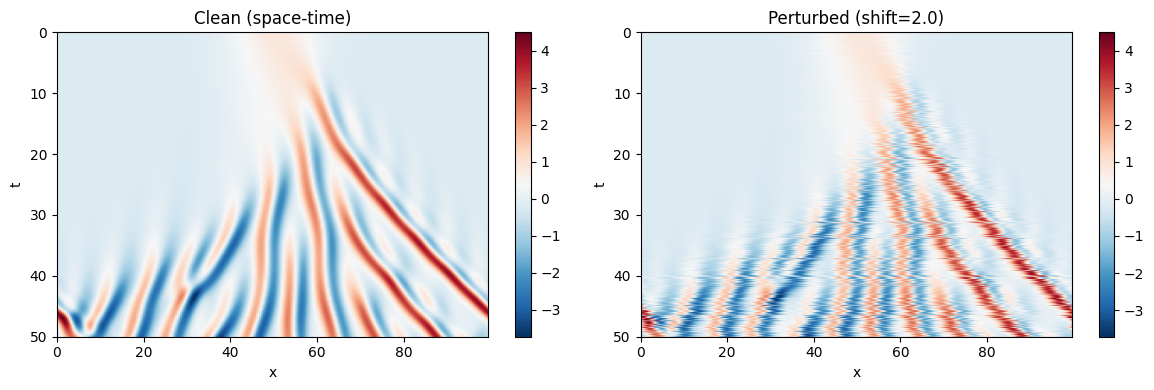

In [3]:
# Quick visualization of one example trajectory (space-time plot)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

im0 = axes[0].imshow(u_clean, aspect='auto', cmap='RdBu_r',
                     extent=[x[0], x[-1], t_clean[-1], t_clean[0]])
axes[0].set_title('Clean (space-time)')
axes[0].set_xlabel('x')
axes[0].set_ylabel('t')
plt.colorbar(im0, ax=axes[0])

if u_pert is not None:
    im1 = axes[1].imshow(u_pert, aspect='auto', cmap='RdBu_r',
                         extent=[x[0], x[-1], t_pert[-1], t_pert[0]])
    axes[1].set_title(f'Perturbed (shift={example_shift})')
    axes[1].set_xlabel('x')
    axes[1].set_ylabel('t')
    plt.colorbar(im1, ax=axes[1])
else:
    axes[1].axis('off')

plt.tight_layout()
plt.show()

## 2. Domain Adaptation Dataset

We now define a PyTorch `Dataset` that:
- Samples individual snapshots `u(t, x)` from clean and perturbed datasets.
- Assigns **domain labels**: 0 for clean, 1 for perturbed.

These snapshots will be inputs to a feature extractor; the domain labels will be used by a domain discriminator.

In [4]:
class SnapshotDomainDataset(Dataset):
    """Snapshot-level dataset for domain adaptation.

    Each sample is a 1D spatial profile u(x) at a given time t.
    Domain label: 0 = clean, 1 = perturbed.
    """
    def __init__(self, clean_files, perturbed_files, max_files_per_domain=None, max_snapshots_per_file=50):
        self.samples = []  # list of (file_path, time_index, domain_label)

        def collect_samples(files, domain_label):
            if max_files_per_domain is not None:
                files_local = files[:max_files_per_domain]
            else:
                files_local = files
            for fp in files_local:
                with h5py.File(fp, 'r') as f:
                    u = f['u']
                    T = u.shape[0]
                # Sample up to max_snapshots_per_file uniformly over time
                if T <= max_snapshots_per_file:
                    t_indices = list(range(T))
                else:
                    t_indices = np.linspace(0, T - 1, max_snapshots_per_file, dtype=int)
                for ti in t_indices:
                    self.samples.append((fp, int(ti), int(domain_label)))

        collect_samples(clean_files, domain_label=0)
        collect_samples(perturbed_files, domain_label=1)

        print(f"Total snapshots: {len(self.samples)} (clean + perturbed)")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        fp, t_idx, domain = self.samples[idx]
        with h5py.File(fp, 'r') as f:
            u = f['u'][t_idx]  # shape: (N,)
        # Normalize each snapshot to zero mean and unit std for stability
        u = u.astype(np.float32)
        u_mean = u.mean()
        u_std = u.std() + 1e-8
        u_norm = (u - u_mean) / u_std

        # Add channel dimension for Conv1d: (C=1, N)
        u_tensor = torch.from_numpy(u_norm)[None, :]
        domain_tensor = torch.tensor(domain, dtype=torch.long)
        return u_tensor, domain_tensor


# Build a small dataset for prototyping
dataset = SnapshotDomainDataset(clean_files, perturbed_files,
                                max_files_per_domain=10,
                                max_snapshots_per_file=50)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True, drop_last=True)

batch_u, batch_domain = next(iter(dataloader))
print(f"Batch u shape: {batch_u.shape}  (B, C, N)")
print(f"Batch domain shape: {batch_domain.shape}")

Total snapshots: 1000 (clean + perturbed)
Batch u shape: torch.Size([32, 1, 256])  (B, C, N)
Batch domain shape: torch.Size([32])


## 3. Feature Extractor, Gradient Reversal, and Domain Discriminator

We implement a simple 1D convolutional feature extractor and a small MLP domain discriminator:

- `FeatureExtractor`: maps `u(x)` → feature vector `z ∈ R^64`.
- `DomainDiscriminator`: maps `z` → domain logits (clean vs perturbed).
- `GradientReversal`: passes features unchanged in the forward pass, but **reverses the gradient** during backprop to encourage domain-invariant features.

We will first train a plain domain classifier, then enable the gradient reversal layer for adversarial training.

In [5]:
from torch.autograd import Function


class GradientReversalFunction(Function):
    """Implements the gradient reversal layer (GRL).

    Forward: identity.
    Backward: multiplies incoming gradient by -lambda_.
    """
    @staticmethod
    def forward(ctx, x, lambda_):
        ctx.lambda_ = lambda_
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.lambda_ * grad_output, None


class GradientReversal(nn.Module):
    def __init__(self, lambda_=1.0):
        super().__init__()
        self.lambda_ = lambda_

    def forward(self, x):
        return GradientReversalFunction.apply(x, self.lambda_)

class FeatureExtractor(nn.Module):
    def __init__(self, in_channels=1, hidden_channels=(16, 32), feature_dim=64):
        super().__init__()
        c1, c2 = hidden_channels
        self.conv1 = nn.Conv1d(in_channels, c1, kernel_size=5, padding=2)
        self.conv2 = nn.Conv1d(c1, c2, kernel_size=5, padding=2)
        self.act = nn.ReLU(inplace=True)
        self.pool = nn.AdaptiveAvgPool1d(1)  # global average pooling over x
        self.fc = nn.Linear(c2, feature_dim)

    def forward(self, x):
        # x: (B, C=1, N)
        x = self.act(self.conv1(x))
        x = self.act(self.conv2(x))
        x = self.pool(x).squeeze(-1)  # (B, C2)
        z = self.fc(x)  # (B, feature_dim)
        return z


class DomainDiscriminator(nn.Module):
    def __init__(self, feature_dim=64, hidden_dim=64, num_domains=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(feature_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, num_domains)
        )

    def forward(self, z):
        return self.net(z)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
feature_extractor = FeatureExtractor().to(device)
domain_discriminator = DomainDiscriminator().to(device)
grl = GradientReversal(lambda_=1.0).to(device)

print(feature_extractor)
print(domain_discriminator)
print(grl)

FeatureExtractor(
  (conv1): Conv1d(1, 16, kernel_size=(5,), stride=(1,), padding=(2,))
  (conv2): Conv1d(16, 32, kernel_size=(5,), stride=(1,), padding=(2,))
  (act): ReLU(inplace=True)
  (pool): AdaptiveAvgPool1d(output_size=1)
  (fc): Linear(in_features=32, out_features=64, bias=True)
)
DomainDiscriminator(
  (net): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=64, out_features=2, bias=True)
  )
)
GradientReversal()


## 4. Domain Classification Training – Supervised vs Adversarial

We train the domain classifier in two modes:

1. **Supervised domain classification (no GRL):**
   - Checks how easily clean vs perturbed domains are separable.
2. **Adversarial training (with GRL):**
   - Uses the gradient reversal layer so that the feature extractor is trained to *fool* the domain discriminator (learn domain-invariant features).

Training objective in both cases:
- Cross-entropy loss on domain labels.
- Metrics: domain classification accuracy (in adversarial mode, lower accuracy indicates stronger invariance).

In [6]:
NUM_EPOCHS = 5
LR = 1e-3

# 1) Supervised domain classification (no GRL)
optimizer = torch.optim.Adam(list(feature_extractor.parameters()) +
                             list(domain_discriminator.parameters()), lr=LR)
criterion = nn.CrossEntropyLoss()

print("Supervised domain classification (no GRL):")
for epoch in range(1, NUM_EPOCHS + 1):
    feature_extractor.train()
    domain_discriminator.train()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for u_batch, domain_batch in dataloader:
        u_batch = u_batch.to(device)
        domain_batch = domain_batch.to(device)

        optimizer.zero_grad()

        z = feature_extractor(u_batch)
        logits = domain_discriminator(z)
        loss = criterion(logits, domain_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * u_batch.size(0)
        preds = logits.argmax(dim=1)
        total_correct += (preds == domain_batch).sum().item()
        total_samples += u_batch.size(0)

    avg_loss = total_loss / total_samples
    acc = total_correct / total_samples
    print(f"  Epoch {epoch:02d}: loss={avg_loss:.4f}, domain acc={acc:.3f}")

print("\n✓ Supervised domain classifier training complete")

# 2) Adversarial training with gradient reversal
# Re-initialize models to compare fairly (optional but clearer)
feature_extractor = FeatureExtractor().to(device)
domain_discriminator = DomainDiscriminator().to(device)
grl = GradientReversal(lambda_=1.0).to(device)

optimizer_adv = torch.optim.Adam(list(feature_extractor.parameters()) +
                                 list(domain_discriminator.parameters()), lr=LR)

print("\nAdversarial domain training (with GRL):")
for epoch in range(1, NUM_EPOCHS + 1):
    feature_extractor.train()
    domain_discriminator.train()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for u_batch, domain_batch in dataloader:
        u_batch = u_batch.to(device)
        domain_batch = domain_batch.to(device)

        optimizer_adv.zero_grad()

        # Features
        z = feature_extractor(u_batch)
        # Apply gradient reversal before domain discriminator
        z_rev = grl(z)
        logits = domain_discriminator(z_rev)
        loss = criterion(logits, domain_batch)
        loss.backward()
        optimizer_adv.step()

        total_loss += loss.item() * u_batch.size(0)
        preds = logits.argmax(dim=1)
        total_correct += (preds == domain_batch).sum().item()
        total_samples += u_batch.size(0)

    avg_loss = total_loss / total_samples
    acc = total_correct / total_samples
    print(f"  Epoch {epoch:02d}: loss={avg_loss:.4f}, domain acc={acc:.3f}")

print("\n✓ Adversarial domain training complete (low accuracy ⇒ more domain-invariant features)")

Supervised domain classification (no GRL):
  Epoch 01: loss=0.6939, domain acc=0.510
  Epoch 02: loss=0.6863, domain acc=0.558
  Epoch 03: loss=0.6625, domain acc=0.614
  Epoch 04: loss=0.6297, domain acc=0.664
  Epoch 05: loss=0.6179, domain acc=0.673

✓ Supervised domain classifier training complete

Adversarial domain training (with GRL):
  Epoch 01: loss=0.6941, domain acc=0.376
  Epoch 02: loss=0.6954, domain acc=0.453
  Epoch 03: loss=0.6955, domain acc=0.500
  Epoch 04: loss=0.6961, domain acc=0.462
  Epoch 05: loss=0.6947, domain acc=0.497

✓ Adversarial domain training complete (low accuracy ⇒ more domain-invariant features)


## 5. Next Steps (Towards Domain-Adaptive SINDy)

This notebook now provides:
- A snapshot-level domain adaptation dataset.
- A feature extractor and domain discriminator.
- Both supervised and adversarial (GRL-based) domain training.

Next steps for future work:
1. Use the adversarially trained `feature_extractor` to compute features for full KS trajectories (clean and perturbed).
2. Design a way to integrate these features into **SINDy** (e.g., learn a mapping from features back to physical space or build a SINDy library directly in feature space).
3. Compare domain-adapted SINDy to:
   - Baseline SINDy (Notebook 02).
   - OT registration + SINDy (Notebook 03).
